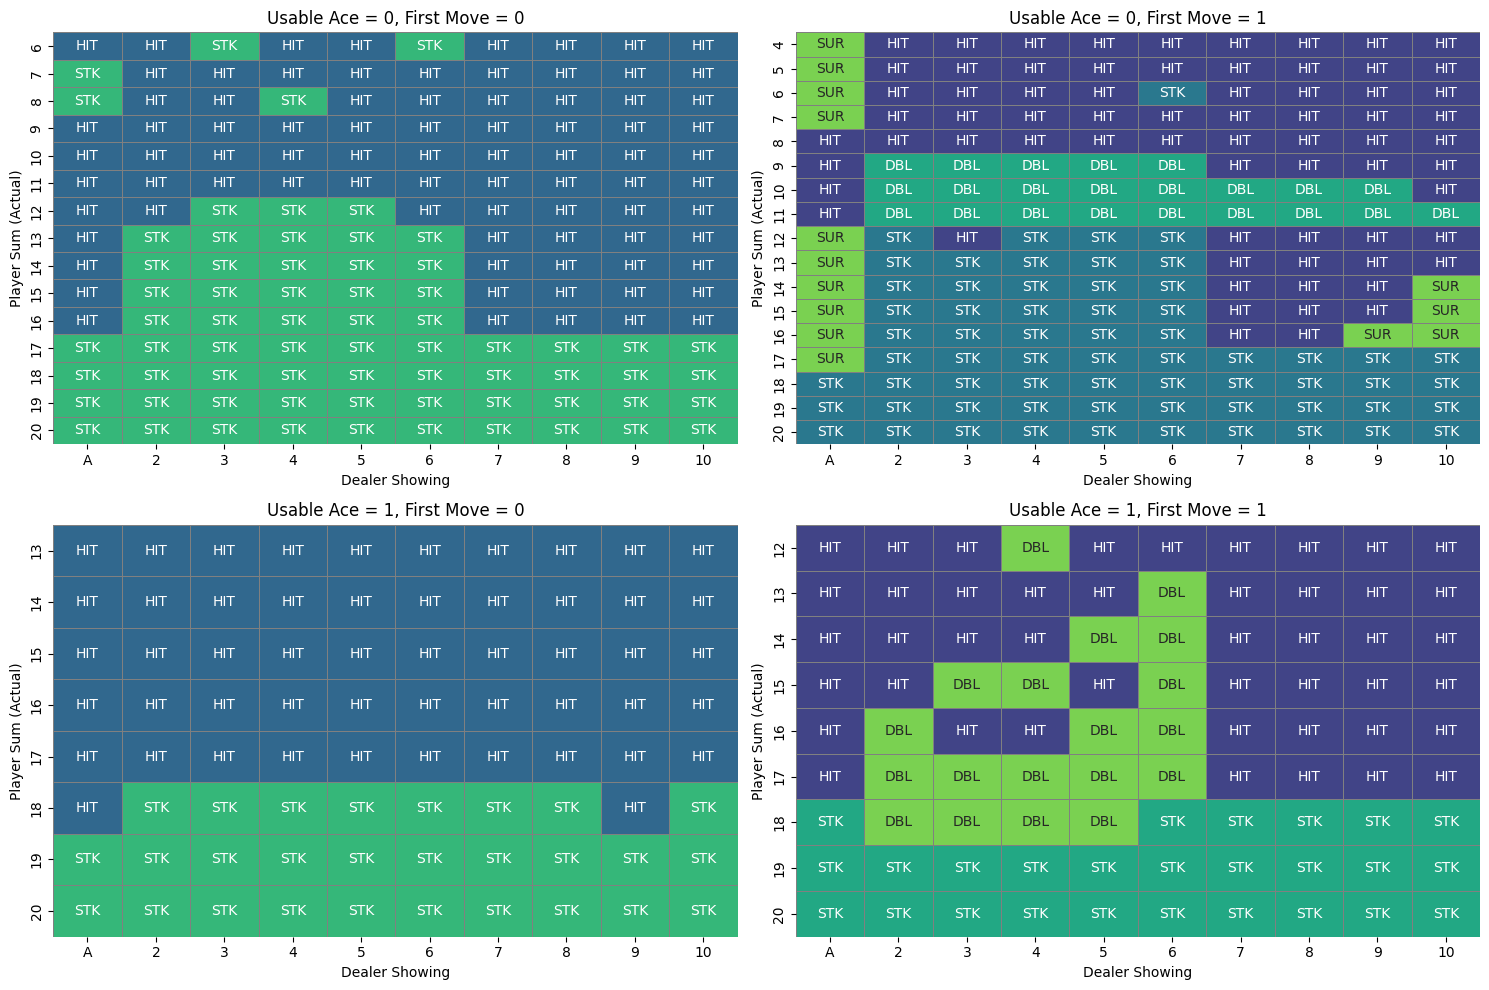

In [ ]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the model weights and policies
with open("../model-weights/blackjack-with-extended-action-space-and-rewards.pkl", "rb") as f:
    Q_loaded, policy_loaded = pickle.load(f)

def generate_strategy_chart(usable_ace, first_move):
    """
    Generates a pandas DataFrame for the strategy chart.
    
    Parameters:
        usable_ace (int): 0 or 1.
        first_move (int): 0 or 1.
        
    Returns:
        df (pd.DataFrame): DataFrame with player sum as index (actual sum) and dealer card as columns.
    """
    # Define the range for player_sum:
    # If usable_ace==0, saved player_sum can be 2 to 20.
    # If usable_ace==1, saved player_sum can be 2 to 10 (since actual sum = saved + 10, which gives 12 to 20).
    if usable_ace == 0 and first_move == 0: # 6 to 20 which maps to actual sums 6 to 20
        player_range = range(6, 21)
    if usable_ace == 1 and first_move == 0: # 3 to 10 which maps to actual sums 13 to 20
        player_range = range(3, 11)
    elif usable_ace == 0 and first_move == 1:
        player_range = range(4, 21)  # 4 to 20 which maps to actual sums 4 to 20
    elif usable_ace == 1 and first_move == 1:
        player_range = range(2, 11)  # 2 to 10, which maps to actual sums 12 to 20
    
    # Dealer sum: 1 (Ace) and 2 to 10
    dealer_range = range(1, 11)
    
    # Build the data grid: rows = player's actual sum, columns = dealer's showing card
    data = []
    row_labels = []
    
    for player_sum in player_range:
        # Calculate actual player sum. For usable_ace==1, add 10.
        actual_player_sum = player_sum + 10 if usable_ace else player_sum
        
        # Skip if actual player sum is 21 or more (natural blackjack or bust)
        if actual_player_sum >= 21:
            continue
        
        row = []
        row_labels.append(actual_player_sum)
        for dealer_sum in dealer_range:
            # Create the state as per your specification:
            # state = [actual_player_sum, dealer_sum, usable_ace, first_move]
            state = [actual_player_sum, dealer_sum, usable_ace, first_move]
            # Note: we use tuple(state) as the key if your dictionary keys are tuples.
            action = policy_loaded.get(tuple(state), 1)  # default to STK (1) if state not found
            
            # Map the action number to a label based on allowed actions:
            if first_move:
                action_map = {0: 'HIT', 1: 'STK', 2: 'DBL', 3: 'SUR'}
            else:
                action_map = {0: 'HIT', 1: 'STK'}
            action_label = action_map.get(action, 'UNK') # default to 'UNK' if action not found
            row.append(action_label)
        data.append(row)
    
    # Dealer's column labels: display 1 as "A" (Ace) and 2-10 as-is.
    col_labels = ['A'] + [i for i in range(2, 11)]
    df = pd.DataFrame(data, index=row_labels, columns=col_labels)
    return df

# Prepare the four cases: 
# (usable_ace, first_move) pairs:
cases = [(0, 0), (0, 1), (1, 0), (1, 1)]
titles = {
    (0, 0): "Usable Ace = 0, First Move = 0",
    (0, 1): "Usable Ace = 0, First Move = 1",
    (1, 0): "Usable Ace = 1, First Move = 0",
    (1, 1): "Usable Ace = 1, First Move = 1"
}

# Create subplots for each chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (usable_ace, first_move) in enumerate(cases):
    df = generate_strategy_chart(usable_ace, first_move)
    ax = axes[i]
    
    # For visualization, map action strings to numbers (for color coding)
    if first_move:
        action_map_num = {'HIT': 0, 'STK': 1, 'DBL': 2, 'SUR': 3}
        # Improved color grading using a sequential colormap with smooth transitions
        cmap = sns.color_palette("viridis", 4)
    else:
        action_map_num = {'HIT': 0, 'STK': 1}
        cmap = sns.color_palette("viridis", 2)
    
    # Convert the DataFrame to numeric values for heatmap coloring
    numeric_df = df.copy()
    for col in numeric_df.columns:
        numeric_df[col] = numeric_df[col].map(action_map_num)
    
    # Plot the heatmap with annotations (the text will be the actual action labels)
    sns.heatmap(numeric_df, annot=df, fmt='', cmap=cmap, cbar=False, ax=ax, linewidths=0.5, linecolor='gray')
    ax.set_title(titles[(usable_ace, first_move)])
    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum (Actual)")
    
plt.tight_layout()
plt.show()

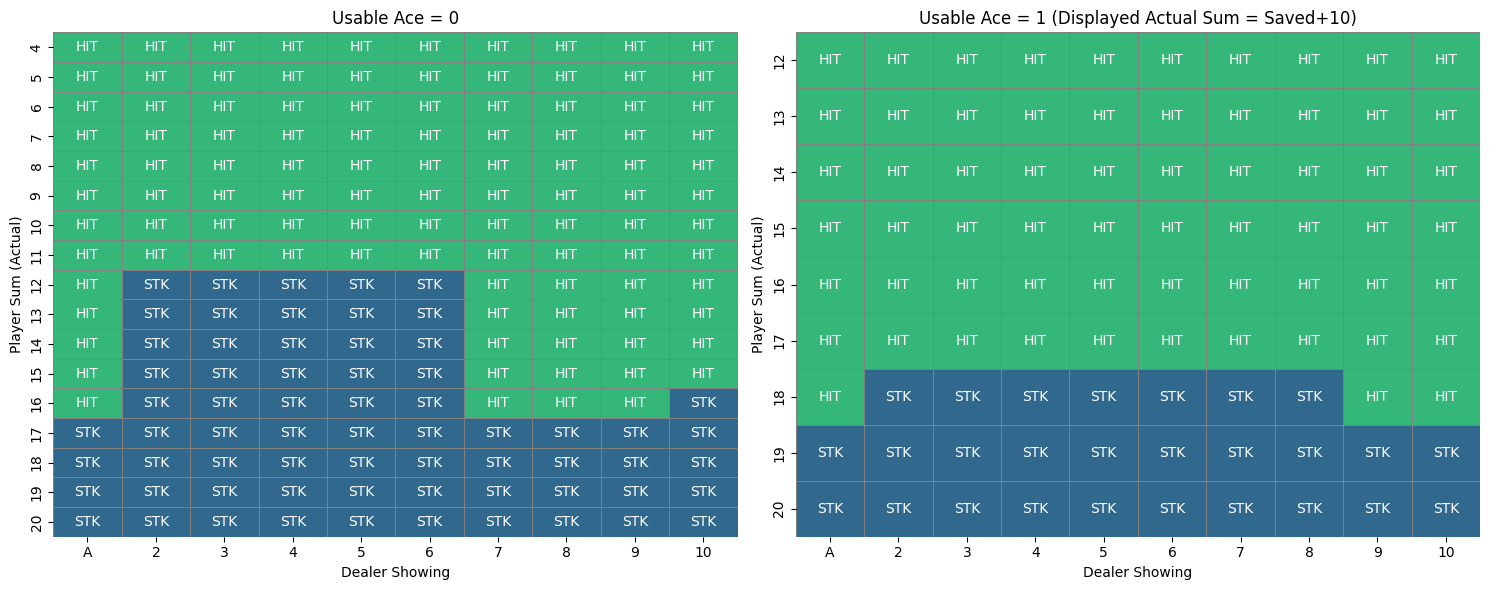

In [26]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the model weights and policies for the simpler blackjack-v1 model
with open("../model-weights/blackjack_model-v1.pkl", "rb") as f:
    Q_loaded, policy_loaded = pickle.load(f)

def generate_strategy_chart_simple(usable_ace):
    """
    Generates a pandas DataFrame for the simpler blackjack-v1 strategy chart.
    
    Parameters:
        usable_ace (int): 0 or 1.
        
    Returns:
        df (pd.DataFrame): DataFrame with player sum (actual) as index and dealer card as columns.
    """
    # For usable_ace=0: saved player sum is exactly the actual sum,
    # and we want to show values from 4 to 20.
    if usable_ace == 0:
        player_range = range(4, 21)  # 4 to 20 (we skip 21 since it's terminal)
    else:
        # For usable ace, we assume saved player sum is between 2 and 10 
        # because actual sum = saved sum + 10. (Displayed actual sum will be 12 to 20)
        player_range = range(2, 11)
    
    # Dealer showing card: 1 (Ace) and 2-10
    dealer_range = range(1, 11)
    
    data = []
    row_labels = []
    
    for player_sum in player_range:
        # For usable ace=1, adjust the displayed actual sum
        actual_player_sum = player_sum + 10 if usable_ace else player_sum
        
        # Skip if actual player sum reaches 21 or more.
        if actual_player_sum >= 21:
            continue
        
        row_labels.append(actual_player_sum)
        row = []
        for dealer_sum in dealer_range:
            # Create state as defined in the simpler model.
            state = [actual_player_sum, dealer_sum, usable_ace]
            # We use tuple(state) as key for policy_loaded
            action = policy_loaded.get(tuple(state), 0)  # default to STK (0) if state not found
            
            # Map action to labels (only two actions are allowed)
            action_map = {0: 'STK', 1: 'HIT'}
            action_label = action_map.get(action, 'UNK')
            row.append(action_label)
        data.append(row)
    
    # Column labels: display dealer 1 as "A" and 2-10 as-is.
    col_labels = ['A'] + [i for i in range(2, 11)]
    df = pd.DataFrame(data, index=row_labels, columns=col_labels)
    return df

# Prepare the two cases:
cases = [0, 1]
titles = {0: "Usable Ace = 0", 1: "Usable Ace = 1 (Displayed Actual Sum = Saved+10)"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, usable_ace in enumerate(cases):
    df = generate_strategy_chart_simple(usable_ace)
    ax = axes[i]
    
    # Map action strings to numbers for color coding:
    # Since action space is 0 (STK) and 1 (HIT)
    action_map_num = {'STK': 0, 'HIT': 1}
    cmap = sns.color_palette("viridis", 2)
    
    # Convert DataFrame to numeric values for heatmap coloring
    numeric_df = df.copy()
    for col in numeric_df.columns:
        numeric_df[col] = numeric_df[col].map(action_map_num)
    
    # Plot heatmap with annotations for action labels
    sns.heatmap(numeric_df, annot=df, fmt='', cmap=cmap, cbar=False, ax=ax, linewidths=0.5, linecolor='gray')
    ax.set_title(titles[usable_ace])
    ax.set_xlabel("Dealer Showing")
    ax.set_ylabel("Player Sum (Actual)")
    
plt.tight_layout()
plt.show()